### Loading data and initial analisys

Status  Alive  Dead   All
Smoker                   
No        502   230   732
Yes       443   139   582
All       945   369  1314

Mortality Rates:
Status     Alive      Dead
Smoker                    
No      0.685792  0.314208
Yes     0.761168  0.238832


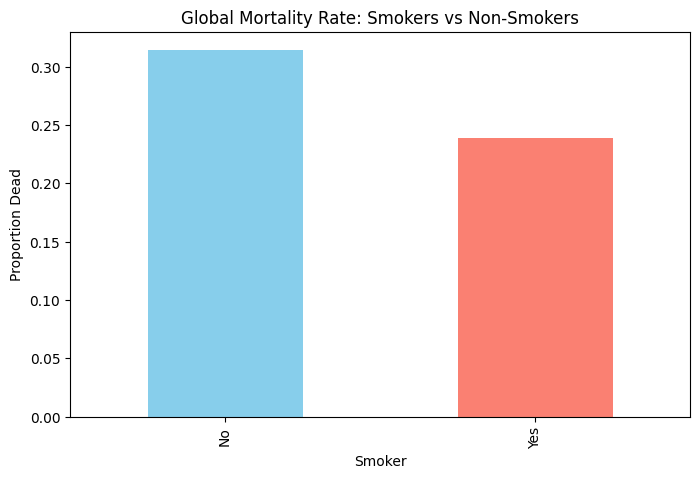

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = pd.read_csv('Subject6_smoking.csv')

mortality_table = pd.crosstab(df['Smoker'], df['Status'], margins=True)
mortality_rates = pd.crosstab(df['Smoker'], df['Status'], normalize='index')

print(mortality_table)
print("\nMortality Rates:")
print(mortality_rates)

mortality_rates['Dead'].plot(kind='bar', color=['skyblue', 'salmon'], figsize=(8, 5))
plt.title('Global Mortality Rate: Smokers vs Non-Smokers')
plt.ylabel('Proportion Dead')
plt.show()

At first glace result seems counter-intuitive:the mortality of non-smoker is higher,than mortality of smokers

### Aggregation by age

Status               Alive      Dead
age_group Smoker                    
18-34     No      0.972477  0.027523
          Yes     0.971751  0.028249
35-54     No      0.904523  0.095477
          Yes     0.827004  0.172996
55-64     No      0.669421  0.330579
          Yes     0.556522  0.443478
65+       No      0.145078  0.854922
          Yes     0.142857  0.857143


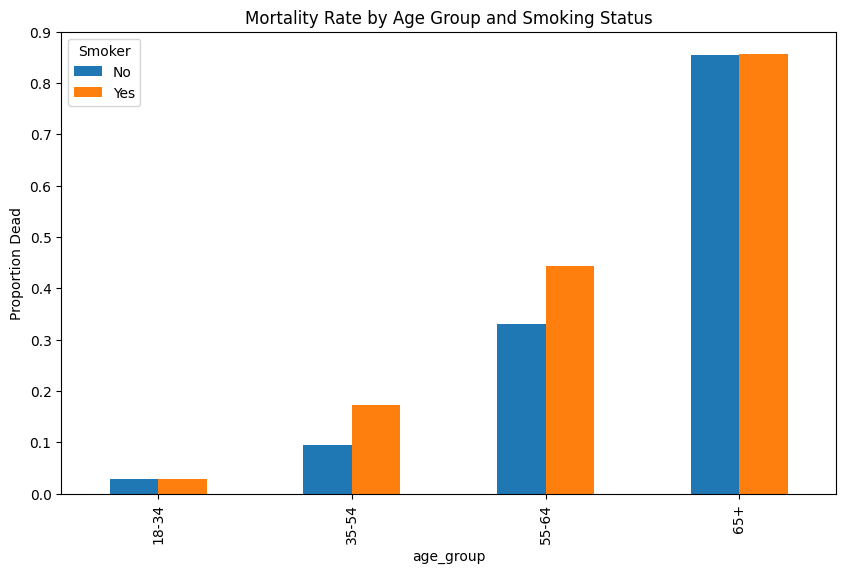

In [6]:
bins = [18, 34, 54, 64, 100]
labels = ['18-34', '35-54', '55-64', '65+']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

stratified_data = pd.crosstab([df['age_group'], df['Smoker']], df['Status'], normalize='index')
print(stratified_data)

stratified_data['Dead'].unstack().plot(kind='bar', figsize=(10, 6))
plt.title('Mortality Rate by Age Group and Smoking Status')
plt.ylabel('Proportion Dead')
plt.legend(title='Smoker')
plt.show()

But if we devide the data by age groups, the pardox is resolved!
In 2 of 4 groups smokers have higher mortality (And first and last groups not quite fair,in first group damage cause of smoking not so significant due to low duration of smoking.And equity of the mortality in 65+ group it's just a survivalship bias)

### Logistic Regression Modeling

In [ ]:
# Encoding outcome as binary: 1 for Dead, 0 for Alive
df['Death'] = (df['Status'] == 'Dead').astype(int)

model = smf.logit('Death ~ Age + Smoker', data=df).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.381244
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Death   No. Observations:                 1314
Model:                          Logit   Df Residuals:                     1311
Method:                           MLE   Df Model:                            2
Date:                Tue, 03 Feb 2026   Pseudo R-squ.:                  0.3579
Time:                        21:45:33   Log-Likelihood:                -500.95
converged:                       True   LL-Null:                       -780.16
Covariance Type:            nonrobust   LLR p-value:                5.534e-122
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -6.3519      0.360    -17.637      0.000      -7.058      -5.646
Smoker[T.Yes]     0.

The logistic regression shows that when age is controlled, smoking has a positive coef (0.2787),it indicates an increased risk of the mortality
This resolves Simpson Paradox: the raw data suggestion that smoking is "beneficial" was a result of the non-smoking group being significantly older The regression demonstrates the harmfulness of smoking once age-related bias is removed.

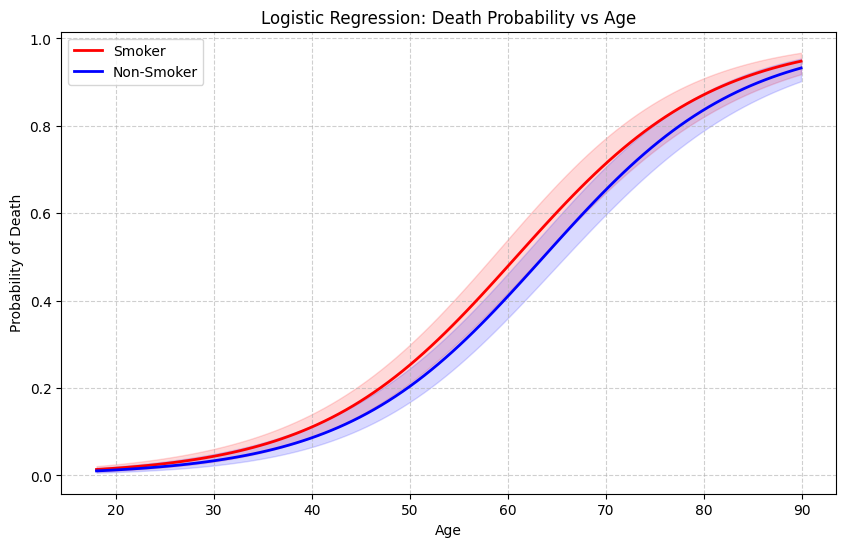

In [13]:
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100)
predict_smoker = pd.DataFrame({'Age': age_range, 'Smoker': 'Yes'})
predict_non_smoker = pd.DataFrame({'Age': age_range, 'Smoker': 'No'})

res_s = model.get_prediction(predict_smoker).summary_frame()
res_ns = model.get_prediction(predict_non_smoker).summary_frame()

plt.figure(figsize=(10, 6))

# Using .iloc to avoid KeyError (0 = mean, 2 = lower CI, 3 = upper CI)
plt.plot(age_range, res_s.iloc[:, 0], label='Smoker', color='red', lw=2)
plt.fill_between(age_range, res_s.iloc[:, 2], res_s.iloc[:, 3], color='red', alpha=0.15)

plt.plot(age_range, res_ns.iloc[:, 0], label='Non-Smoker', color='blue', lw=2)
plt.fill_between(age_range, res_ns.iloc[:, 2], res_ns.iloc[:, 3], color='blue', alpha=0.15)

plt.xlabel('Age')
plt.ylabel('Probability of Death')
plt.title('Logistic Regression: Death Probability vs Age')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The graph shows that the probability of death for smokers (red line) is consistently higher than for non-smokers throughout their lives. For example, at the age of 60, the risk of death for smokers is about 0.45, while for non-smokers it is lower by about 0.4.

### Conclusion

The statistical paradox in the raw totals was effectively resolved by adjusting for the age related bias. Consequently, the graphical and mathematical evidence confirms the harmfulness of smoking once the underlying age distribution is properly controlled.